In [1]:
import numpy as np
import sys
import os
from dftpy.field import *
from dftpy.grid import *
from dftpy.functionals import FunctionalClass, TotalEnergyAndPotential
from dftpy.pseudo import LocalPseudo
from dftpy.formats import io, ase_io
from dftpy.math_utils import bestFFTsize
from dftpy.time_data import TimeData
from dftpy.optimization import Optimization
from dftpy.constants import LEN_CONV, ENERGY_CONV
from dftpy.system import System
import ase.io
import ml_dft.dft_utils as du
%load_ext autoreload
%autoreload 2

Use "numpy" for Fourier Transform


In [2]:
data_dir = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/datasets/'

In [3]:
def MakeGrid(metric,gap):
    nr = np.zeros(3, dtype = 'int32')
    for i in range(3):
        nr[i] = int(np.sqrt(metric[i, i])/gap)
    print('The initial grid size is ', nr)
    for i in range(3):
        nr[i] = bestFFTsize(nr[i])
    print('The final grid size is ', nr)
    grid = DirectGrid(lattice=lattice, nr=nr, units=None, full=False)
    return grid

def guess_rho(grid,ions):
    charge_total = 0.0
    zerosA = np.zeros(grid.nnr, dtype=float)
    rho_ini = DirectField(grid=grid, griddata_F=zerosA, rank=1)
    for i in range(ions.nat) :
        charge_total += ions.Zval[ions.labels[i]]
    rho_ini[:] = charge_total/ions.pos.cell.volume
    return rho_ini

In [44]:
data = np.load(data_dir + 'h2o_overlap_static_centered.npy', allow_pickle=True).item()
npy_pos = data['positions']
print('pos shape', npy_pos.shape)
ase_pos = du.npy_to_ase(npy_pos, data['atom_types'])
ions_list = []
for a in ase_pos:
    a.set_cell([4.1483, 4.1483, 4.1483])
    a.set_positions(a.positions + (2.0318))
    ions_list.append(ase_io.ase2ions(a))
    
for ions in ions_list:
    print(ions)
    
    
lattice = ions.pos.cell.lattice
metric = np.dot(lattice.T, lattice)
print('lattice shape', lattice.shape)
print('metric shape', metric.shape)

gap = 0.4
grid = MakeGrid(metric,gap)

pos shape (18, 3, 3)
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.70291571 3.70291571]
 [3.64632177 5.13473152 5.13473152]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.83954554 3.64632177]
 [3.64632177 3.83954554 5.67121512]]
                 nat : 3
                   Z : [8 1 1]
              labels : ['O' 'H' 'H']
                Zval : {}
                 pos : [[3.83954554 3.83954554 3.83954554]
 [5.67121512 3.64632177 3.83954554]
 [3.64632177 5.67121512 3.83954554]]
                 nat : 3
                   Z : [8 1 1]
            

In [45]:
print('ions zval', ions.Zval)
print('ions labels', ions.labels)

ions zval {}
ions labels ['O' 'H' 'H']


In [46]:
path_pp = '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/'
file_names = {'H': 'H.pbe-kjpaw_psl.0.1.UPF', 'C': 'C.pbe-kjpaw_psl.0.1.UPF',
             'O': 'O.pbe-n-kjpaw_psl.0.1.UPF'}
PP_list = {key: path_pp+file_names[key] for key in file_names.keys()}
print(PP_list)
PSEUDO = LocalPseudo(grid = grid, ions=None, PP_list=PP_list,PME=True)

{'H': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/H.pbe-kjpaw_psl.0.1.UPF', 'C': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/C.pbe-kjpaw_psl.0.1.UPF', 'O': '/home/mihail/Documents/workspace/schnet-tfn/equiv_dens/pseudo_potentials/O.pbe-n-kjpaw_psl.0.1.UPF'}
setting key: H
setting key: C
setting key: O


In [47]:
init_rhos = []
for ions in ions_list:
    PSEUDO.restart(grid=grid, ions=ions)
    rho_ini = guess_rho(grid, ions)
    init_rhos.append(rho_ini)

#rho_ini = guess_rho(grid,ions)

In [48]:
optional_kwargs = {}
KE = FunctionalClass(type='KEDF',name='x_TF_y_vW',optional_kwargs=optional_kwargs)
XC = FunctionalClass(type='XC',name='LDA')
HARTREE = FunctionalClass(type='HARTREE')

In [49]:
optimization_options = {\
        'econv' : 1e-6, # Energy Convergence (a.u./atom)
        'maxfun' : 50,  # For TN method, it's the max steps for searching direction
        'maxiter' : 100,# The max steps for optimization
        }
optimization_options["econv"] *= ions.nat


In [50]:
opt_rhos = []
for i in range(len(init_rhos)):
    rho = init_rhos[i]
    ions = ions_list[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    opt = Optimization(EnergyEvaluator=E_v_Evaluator, optimization_options = optimization_options,
        optimization_method = 'TN')

    new_rho = opt.optimize_rho(guess_rho=rho)
    opt_rhos.append(new_rho)

evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy 1.6779869639474494e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476593
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.507701E+00    1       1       3.115535E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
!WARN: Change to steepest decent
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.6068758570970911
evalfunctional XC
evalfunctional LDA
energy -1.8547026421708608
evalfunctional HARTREE
evalfunctional HARTREE
energy 0.048272908487895755
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -1.811773742303587
evalfunctional KEDF
evalfunctional x_TF_

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalf

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.994610140094544
evalfunctional XC
evalfunctional LDA
energy -3.3089657474510026
evalfunctional HARTREE
evalfunctional HARTREE
energ

...

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctiona

evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.014684988446017
evalfunctional XC
evalfun

evalfunctional XC
evalfunctional LDA
energy -3.3088123362975748
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.384634192746017
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.136875364024664
11      -1.106843001745E+01     -2.017149E-07   3.244735E-07    10      2       1.664778E+00    
#### Density Optimization Converged ####
Chemical potential (a.u.): -0.13323563350667356
Chemical potential (eV)  : -3.625525909610734
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy 1.6779869639474494e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476694
Step    Energy(a.u.)            dE              dP              Nd      Nls     Time(s)         
0       -2.837784189248E-01     -2.837784E-01   7.507742E+00    1       1       3.136802E-02    
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
eval

evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.084683686478208
evalfunctional XC
evalfunctional LDA
energy -3.3238750181574988
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.465405785198553
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.30293923790523
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 10.025678862285961
evalfunctional XC
evalfunctional LDA
energy -3.3159040735412364
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.427723865980411
evalfunctional PSEUDO
evalfunctional PSEUDO
ene

evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
evalfunctional XC
evalfunctional LDA
evalfunctional HARTREE
evalfunctional HARTREE
evalfunctional PSEUDO
evalfunctional PSEUDO
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.979116908809628
evalfunctional XC
evalfunctional LDA
energy -3.307106983645305
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.381887996125851
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.131035375890075
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.989301595479029
evalfunctional XC
evalfunctional LDA
energy -3.3088739011648753
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.3908627874590405
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.148433743480542
8       -1.107

In [51]:
mols = []
for i in range(len(opt_rhos)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    E_v_Evaluator = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    Enew = E_v_Evaluator.Energy(rho=opt_rho, ions=ions, usePME = True)
    mol = System(ions,cell=grid,name='test',field=opt_rho)
    mols.append(mol)

    print('Energy New (a.u.)', Enew)
    print('Energy New (eV)', Enew * ENERGY_CONV['Hartree']['eV'])
    print('Energy New (eV/atom)', Enew * ENERGY_CONV['Hartree']['eV']/ions.nat)
    print('-' * 31, 'Time information', '-' * 31)
    print("{:28s}{:24s}{:20s}".format('Label', 'Cost(s)', 'Number'))
    for key in TimeData.cost :
        print("{:28s}{:<24.4f}{:<20d}".format(key, TimeData.cost[key], TimeData.number[key]))
    print('-' * 80)

Ewald : -4.493064257090198
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
Energy New (a.u.) -15.570229609435044
Energy New (eV) -423.6874879629515
Energy New (eV/atom) -141.22916265431715
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    56.1371                 38                  
TF                          4.7265                  9738                
vW                          15.1504                 9738                
FFT                         5.9986                  19824               
InvFFT                      6.6925                  19585               
LDA                         13.5700                 9738         

energy 9.993202825592835
evalfunctional XC
evalfunctional LDA
energy -3.3087142654170996
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.3834433316947905
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.13365973250584
Energy New (a.u.) -15.568886177449723
Energy New (eV) -423.6509313200896
Energy New (eV/atom) -141.21697710669653
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    56.1371                 38                  
TF                          4.7335                  9748                
vW                          15.1735                 9748                
FFT                         6.0152                  19864               
InvFFT                      6.7041                  19610               
LDA                         13.5870                 9748                
Hartree_Func                14.1632                 9748       

energy -24.131814760898788
Energy New (a.u.) -15.569365561407496
Energy New (eV) -423.66397602077376
Energy New (eV/atom) -141.22132534025792
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    56.1371                 38                  
TF                          4.7402                  9758                
vW                          15.1943                 9758                
FFT                         6.0299                  19904               
InvFFT                      6.7142                  19635               
LDA                         13.6005                 9758                
Hartree_Func                14.1799                 9758                
Vion_PME                    1.0404                  119                 
Ewald_Energy                0.4356                  75                  
Ewald_Energy_Real           0.2689             

energy -3.3088123362975748
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.384634192746017
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.136875364024664
Energy New (a.u.) -15.569065366471072
Energy New (eV) -423.6558073012556
Energy New (eV/atom) -141.21860243375187
------------------------------- Time information -------------------------------
Label                       Cost(s)                 Number              
Optimize                    56.1371                 38                  
TF                          4.7482                  9770                
vW                          15.2190                 9770                
FFT                         6.0462                  19952               
InvFFT                      6.7254                  19665               
LDA                         13.6168                 9770                
Hartree_Func                14.1994                 9770                
Vion_PME                    1.0893                  

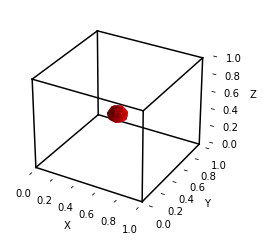

In [52]:
from dftpy.visualize.jupyter import view_density
view_density(mols[0])

In [53]:

for i in range(len(ions_list)):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    rho_ini = init_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    #print(opt_rho.grid.r)
    print('ENERGY new', en_calc.Energy(rho=opt_rho, ions=ions, usePME=False))
    print('ENERGY init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))

L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
ENERGY new -15.570229045976998
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674764885
ENERGY init -4.776842112556918
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.503858764509664
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.989573109233802
evalfunctional XC
evalfunctional LDA
energy -3.3081596927980375
evalfunctional HARTREE
evalfunctional HARTREE
energy 

evalfunctional HARTREE
evalfunctional HARTREE
energy 6.3801537501293
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.12091319630556
ENERGY new -15.568684073065045
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.510241391066939
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.05824582367476533
ENERGY init -4.794019809991704
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.510877528847663
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.98871764903178
evalfunctional XC
evalfunctional LDA
energy -3.307583437831231
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.378683351858419
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.11758531896145
ENERGY new -15.568645284750144
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.510877528847663
evalfunctional KEDF


In [54]:
for i in range(1):
    ions = ions_list[i]
    opt_rho = opt_rhos[i]
    rho_ini = init_rhos[i]
    PSEUDO.restart(grid=grid, ions=ions)
    en_calc = TotalEnergyAndPotential(KineticEnergyFunctional=KE,
                                XCFunctional=XC,
                                HARTREE=HARTREE,
                                PSEUDO=PSEUDO)
    #print(opt_rho.grid.r)
    print('ENERGY new', en_calc.Energy(rho=opt_rho, ions=ions, usePME=False))
    print('ENERGY init', en_calc.Energy(rho=rho_ini, ions=ions, usePME=False))

L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 9.992654992479558
evalfunctional XC
evalfunctional LDA
energy -3.309278543069783
evalfunctional HARTREE
evalfunctional HARTREE
energy 6.392663455669124
evalfunctional PSEUDO
evalfunctional PSEUDO
energy -24.153205257423746
ENERGY new -15.570229045976998
L [7.83915089 7.83915089 7.83915089]
Ewald : -4.493063693632152
evalfunctional KEDF
evalfunctional x_TF_y_vW
energy 1.4951353816791029
evalfunctional XC
evalfunctional LDA
energy -1.8371596242786334
evalfunctional HARTREE
evalfunctional HARTREE
energy -2.2295844065236952e-33
evalfunctional PSEUDO
evalfunctional PSEUDO
energy 0.058245823674764885
ENERGY init -4.776842112556918


In [55]:
from equiv_dens.utils.grids import CubicalGrid
cube_dim = 20
grid_cl = CubicalGrid(None, nx=cube_dim, ny=cube_dim, nz=cube_dim, origin=[0, 0, 0], extent=np.diag(grid.lattice))
#print(grid_cl.coords)

In [58]:
from equiv_dens.density_functionals.LDA import LDAFunctional
from equiv_dens.utils.base import bohr_to_angstrom
import torch
z_vals = []
for t in data['atom_types']:
    z_vals.append(ions.Zval[t])
z_vals = np.array(z_vals)
print(data['atom_numbers'])
print(z_vals)
lda = LDAFunctional(z_vals, verbose=2)
#print('rho ini', rho_ini)
for i in [0]:
    ions = ions_list[i]
    opt_rho = torch.tensor(opt_rhos[i])
    rho_ini = torch.tensor(init_rhos[i])
    #print('rho tensor', rho)
    pos = torch.tensor(ions.pos)    
    atoms = {}
    atoms['shifted_positions'] = bohr_to_angstrom(pos.unsqueeze(0))
    atoms['ions'] = ions_list[i:i+1]
    atoms['density'] = opt_rho.unsqueeze(0)
    atoms['grid'] = grid_cl
    atoms['dftpy_grid'] = grid
    atoms['pseudo_pot'] = PSEUDO
    print(lda(atoms))
    atoms['density'] = rho_ini.unsqueeze(0)
    print(lda(atoms))

[8 1 1]
[6. 1. 1.]
pos tensor([[[3.8395, 3.8395, 3.8395],
         [5.6712, 3.6463, 3.8395],
         [3.6463, 5.6712, 3.8395]]], dtype=torch.float64)
grid <equiv_dens.utils.grids.CubicalGrid object at 0x7f33a13b65f8>
Ewald real energy tensor([0.1912], dtype=torch.float64)
Ewald corr energy tensor(-18.2354, dtype=torch.float64)
Ewald rec energy tensor([13.5512], dtype=torch.float64)
ewald energy tensor([-4.4931], dtype=torch.float64)
thomas fermi energy tensor([6.9590], dtype=torch.float64)
von weizsacker energy tensor([3.0336], dtype=torch.float64)
tf_vw en tensor([9.9927], dtype=torch.float64)
lda energy tensor([-3.3093], dtype=torch.float64)
hartree energy tensor([6.3927], dtype=torch.float64)
pseudo energy tensor([-24.1532], dtype=torch.float64)
{'shifted_positions': tensor([[[2.0318, 2.0318, 2.0318],
         [3.0011, 1.9296, 2.0318],
         [1.9296, 3.0011, 2.0318]]], dtype=torch.float64), 'ions': [<dftpy.atom.Atom object at 0x7f339e1830f0>], 'density': tensor([[[[0.0008, 0.000

In [17]:
import torch.autograd as grad
import time
start = time.time()
opt_rho = torch.tensor(opt_rhos[0])
ions = ions_list[0]
pos = torch.tensor(ions.pos)
PSEUDO.restart(grid=grid, ions=ions)
opt_rho.requires_grad = True
en = lda(opt_rho, grid_cl, pos, PSEUDO)
#print('rho grad', opt_rho.grad)
#en.backward()
#print('rho grad', opt_rho.grad)
print(en)
print(time.time() - start)


rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
rec grid type torch.DoubleTensor
pos type torch.DoubleTensor
ewald energy tensor(-4.1588, dtype=torch.float64)
thomas fermi energy tensor(7.0772, dtype=torch.float64, grad_fn=<AsStridedBackward>)
pot type torch.DoubleTensor
rho type torch.DoubleTensor
von weizsacker energy tensor(3.0779, dtype=torch.float64, grad_fn=<MulBackward0>)
tf_vw en tensor(10.1551, dtype=torch.float64, grad_fn=<AddBackward0>)
lda energy tensor(-3.3359, dtype=torch.float64, grad_fn=<MulBackward0>)
hartree energy tensor(6.5271, dtype=torch.float64, grad_fn=<DivBackward0>)
pseudo energy tensor(-24.6303, dtype=torch.float64, grad_fn=<MulBackward0>)
tensor(-15.4427, dtype=torch.float64, grad_fn=<AddBackward0>)
0.1289048194885254


In [18]:
print('integral = ', torch.sum(opt_rho) * grid.dV)

integral =  tensor(8.0000, dtype=torch.float64, grad_fn=<MulBackward0>)


In [19]:
import torch.fft as tfft
opt_rho = torch.tensor(opt_rhos[0])
opt_rho.requires_grad = True
fft_rho = tfft.rfftn(opt_rho)
ss = torch.sum(fft_rho)
ss.backward()
print(opt_rho.grad)
    

tensor([[[ 6.5000e+04, -1.1937e-12,  2.5000e+03,  ..., -9.5967e-13,
           2.5000e+03,  1.0590e-12],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 0.0000e+00,  0

In [27]:
from equiv_dens.training.density_dataset import AtomsDensityData
from functools import partial
from equiv_dens.training.grids import cubical_grid, cubical_sampling

directory = '2020-10-15_8gYN9fzi'  # load directory name
model_name = '8gYN9fzi'

#directory = '2020-04-30_To0wdEze'
checkpoint_dir = os.path.join(
    directory, 'checkpoints')  # checkpoint directory
# load latest checkpoint
checkpoint = torch.load(os.path.join(
    checkpoint_dir, 'latest_checkpoint.pth'), map_location='cpu')
latest_checkpoint = checkpoint['epoch']
ID = checkpoint['ID']  # load ID
args = checkpoint['args']  # overwrite args
args.use_gpu = False
args.load_from = os.path.join(directory, 'best_' + model_name + '.pth')

In [28]:
use_gpu = args.use_gpu and torch.cuda.is_available()

# load dataset(s)
print("loading density from" + args.dens_dataset + "...")
print("loading atoms from" + args.np_dataset + "...")

# density_file = '/home/mihail/data/water_rot/full_densities.hdf5'
# np_file = 'h2o_overlap_static.npy'

#args.num_workers = 0
#args.dens_dataset = 'datasets/h2o_dynamic_pyscf_dft_f_en.npy'

cube_grid_fn = partial(cubical_grid, nx=cube_dim, ny=cube_dim, nz=cube_dim,
                       extent=np.array([4.1483, 4.1483, 4.1483]),
                       origin=np.array([-2.0318, -2.0318 , -2.0318]))
cube_sampling_fn = cubical_sampling

valid_cube_dataset = AtomsDensityData(np_path=args.np_dataset, density_path=args.dens_dataset,
                                      orbitals_path=args.orbitals_file,
                                      density_n_samp=10000000000,
                                      required_properties=['density'],
                                      center_positions=False,
                                      radial_coeffs_file=args.radial_coeffs_file,
                                      dtype=args.dtype,
                                      grid_fn=cube_grid_fn,
                                      sampling_fn=cube_sampling_fn)

loading density fromdatasets/h2o_dynamic_pyscf_dft.npy...
loading atoms fromdatasets/h2o_dynamic_centered.npy...
Starting atomsdata density init
Some variables
finished init


density shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]
density shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]


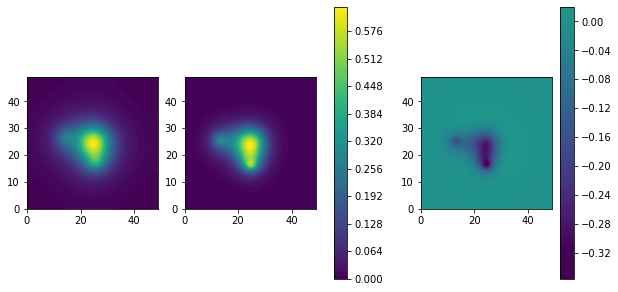

[[3.91957544 3.91957544 3.91957544]
 [2.16767095 4.15899805 2.9744327 ]
 [4.03705215 2.68404984 3.05287341]]


In [29]:
import matplotlib.pyplot as plt
sample = 5

dens_opt = opt_rhos[sample]
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(131)
dens_opt = np.array(dens_opt)
dens_opt = dens_opt.reshape((cube_dim**3, ))
print('density shape', dens_opt.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
dens2d = dens_opt[idx]
dens2d = dens2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(dens2d)
vmax = np.max(dens2d)
c1 = ax1.contourf(x, y, dens2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')

dens_data = np.array(valid_cube_dataset[sample]['density'].squeeze())
print('density shape', dens_data.shape)

ax2 = fig.add_subplot(132)
print('idx', idx)
densd2d = dens_data[idx]
densd2d = densd2d.reshape(cube_dim, cube_dim)

vmin = np.min(densd2d)
vmax = np.max(densd2d)
c2 = ax2.contourf(x, y, densd2d, vmin=vmin, vmax=vmax, levels=100)
ax2.set_aspect('equal')

ax3 = fig.add_subplot(133)
c3 = ax3.contourf(x, y, dens2d-densd2d, vmin=-vmax/2, vmax=vmax/2, levels=100)
ax3.set_aspect('equal')

fig.colorbar(c2, ax=[ax1, ax2])
fig.colorbar(c3, ax=[ax3])
plt.show()
print(ions_list[sample].pos)

In [23]:
print(npy_pos[sample])

[[ 0.          0.          0.        ]
 [-0.92706794  0.12669699 -0.500148  ]
 [ 0.062166   -0.653812   -0.45863897]]


pseudo shape (125000,)
idx [    19   2519   5019 ... 119969 122469 124969]


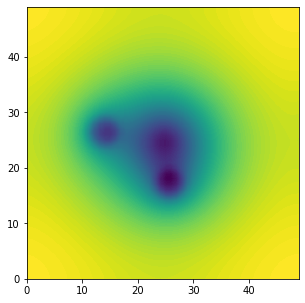

In [30]:
from equiv_dens.training.grids import CubicalGrid

PSEUDO.restart(grid=grid, ions=ions_list[sample])
dens = opt_rhos[5]
PSEUDO(dens)
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)
pot = np.array(PSEUDO.vreal)
pot = pot.reshape((cube_dim**3, ))
print('pseudo shape', pot.shape)
x, y  = np.meshgrid(np.arange(cube_dim), np.arange(cube_dim))
x_f = x.flatten()
y_f = y.flatten()
z_f = np.zeros_like(y_f) + 19
idx = np.ravel_multi_index((x_f, y_f, z_f), (cube_dim, cube_dim, cube_dim))
                
#X, Y, Z = np.meshgrid(np.arange(50) + 38, np.arange(50) + 38, np.arange(50) + 38)
#X = X.flatten()
#Y = Y.flatten()
#Z = Z.flatten()
#ndices = np.ravel_multi_index((X, Y, Z), (125, 125, 125))

print('idx', idx)
pot2d = pot[idx]
pot2d = pot2d.reshape(cube_dim, cube_dim)

indices = np.stack((x_f, y_f, z_f), axis=1)
vmin = np.min(pot2d)
vmax = np.max(pot2d)
c1 = ax1.contourf(x, y, pot2d, vmin=vmin, vmax=vmax, levels=100)
ax1.set_aspect('equal')